<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_modelo_potencuial_precios_cantidad_demanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se trata del conjunto de datos que simula la historia del comporamiento de precio en relaci´pon con la cantidad de demanda de algún negocio que ofrece y vende productos y servicios

Las variables de intepres son:

* precio como variable independiente
* cantidad como variable dependiente

# Objetivo

Construir, validar evaluar un modelo de regresión potencial así como comparar este modelo con otros modelos de regresión con datos que tienen una estructura bivariada.

Algunas tareas a realizar en este caso de estudio que enriquecen el objetivo:

* Se construirán otros cinco modelos de regresión, exponencial, logarítmico y polinomiales de primer, segundo y quinto orden.

* Se validarán los postulados de linealidad, homocedasticidad, normalidad e independencia de los modelos construidos.

* Se comparará la calidad predictiva de los modelos con los estadísticos *r square* y *RMSE*, así mismo se establece que el modelo que no sobrepase un *70%* en el valor de *r square* será un modelo de regresión no óptimo y descartado para la tarea de predicción con estos datos de este contexto.




# Descripción



## Cargar librerías



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.stattools import durbin_watson

from sklearn.model_selection import train_test_split # Partir datos
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf # Para modelo logarítmico

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess

from statsmodels.stats.stattools import durbin_watson

## Cargar funciones



In [2]:
# Aqui se carga
import requests

url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_Mpot.py"

exec(requests.get(url).text)

## Cargar datos

Se cargan lops datos que se encuentran en el enalce  de *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_precio_demanda.csv

In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_precio_demanda.csv"
datos = pd.read_csv(url)

## Visualizar datos

Se visualizan en la **tabla** los primeros y últimos registros del conjunto de datos ejecutando la función *f_visualizar_head_tail_reducido_word()*.



In [4]:
f_visualizar_head_tail_reducido_word(datos)

,precio,cantidad
0,72.88,14.25
1,60.09,13.75
2,22.61,36.37
3,35.72,18.53
4,59.98,14.26
5,12.26,61.61
6,51.96,14.93
7,87.49,7.66
8,32.73,20.03
9,62.27,11.85


## Estadísticos descriptivos

Se muestran los estadísticos y medidas de centralidad y dispersión ejecutando la función *f_describir_datos()*, esta función, arroja como media aritmética de la variable *precio* de *54.81* con desviación estándar de *25.85*; luego una media aritmética de la variable *cantidad* de *18.00* con desviación estándar de *14.87* aproximadamente. Los estadístivos coinciden con el caso de estudio de *R* para los mismos datos.

In [5]:
f_describir_datos(datos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   precio    2000 non-null   float64
 1   cantidad  2000 non-null   float64
dtypes: float64(2)
memory usage: 31.4 KB


{'describe':             precio     cantidad
 count  2000.000000  2000.000000
 mean     54.812705    18.007395
 std      25.853955    14.871312
 min      10.070000     0.100000
 25%      32.250000     8.407500
 50%      54.965000    12.750000
 75%      76.515000    21.907500
 max      99.970000    83.570000,
 'structure': None}

# Desarrollo



## Datos de entrenamiento y datos de validación

Se construyen las particiones de entrenamiento y validación con la función *f_particionar_datos()*; *70%* para datos de entrenamiento y *30%* para datos de validación.


In [6]:
# Particionar datos
particion = f_particionar_datos(datos)

datos_entrenamiento = particion["datos_entrenamiento"]
datos_validacion = particion["datos_validacion"]

f_visualizar_head_tail_reducido_word(datos_entrenamiento)

,precio,cantidad
398,56.5,11.61
1361,58.33,9.87
748,98.45,1.0
689,21.93,35.15
833,64.57,10.23
1801,27.37,25.64
518,36.09,23.17
435,51.34,10.61
936,99.14,7.11
1608,79.5,5.86


In [7]:
f_visualizar_head_tail_reducido_word(datos_validacion)

,precio,cantidad
1179,48.89,7.83
1261,98.44,3.63
1283,37.33,19.05
604,27.59,24.03
1158,75.63,7.58
745,56.43,12.97
1656,41.8,19.8
60,36.86,22.69
26,46.96,16.28
992,70.42,9.15


## Modelo potencial

Con los datos de entrenamiento se construye el modelo de regresión potencial con la función *f_construir_modelo_pot()* que recibe los datos de entrenamiento y los nombres de las variables independinte y dependiente respecivamente.

Los estadóisticos son similares a los del caso de estudio en *R* para estos datos.


In [8]:
modelo_pot = f_construir_modelo_pot(datos_entrenamiento, x="precio", y="cantidad")
print(modelo_pot.summary())

                            OLS Regression Results                            
Dep. Variable:       np.log(cantidad)   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     5137.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:41:41   Log-Likelihood:                -539.07
No. Observations:                1400   AIC:                             1082.
Df Residuals:                    1398   BIC:                             1093.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.1313      0.064    111.

## Construir modelos para comparación

Con funciones vistas en casos de estudio anterioremente descritos, se contruyen los modelos de regresión que servirán de comparación: exponencial, logarítmico, polinomial de primer, segundo y quinto orden; se utilizan los datos de entrenamiento y las variables *"precio"*, *"cantidad"*.


In [9]:
# modelo exponencial
modelo_exp = f_construir_modelo_exp(datos_entrenamiento, "precio", "cantidad")

# modelo logarítmico
modelo_log = f_construir_modelo_log(datos_entrenamiento, "precio", "cantidad")

# modelo lineal primer orden
modelo_RP1 = f_construir_modelo(datos_entrenamiento, "precio", "cantidad", grado=1)

# modelo lineal segundo orden
modelo_RP2 = f_construir_modelo(datos_entrenamiento, "precio", "cantidad", grado=2)

# modelo lineal quinto orden
modelo_RP5 = f_construir_modelo(datos_entrenamiento, "precio", "cantidad", grado=5)

### Postulados de los modelos



#### Linealidad

Se observa linea de tendencia de los seis modelos, visualmente el que mejor se ajustal linealmente es el modelo potencial para estos datos.

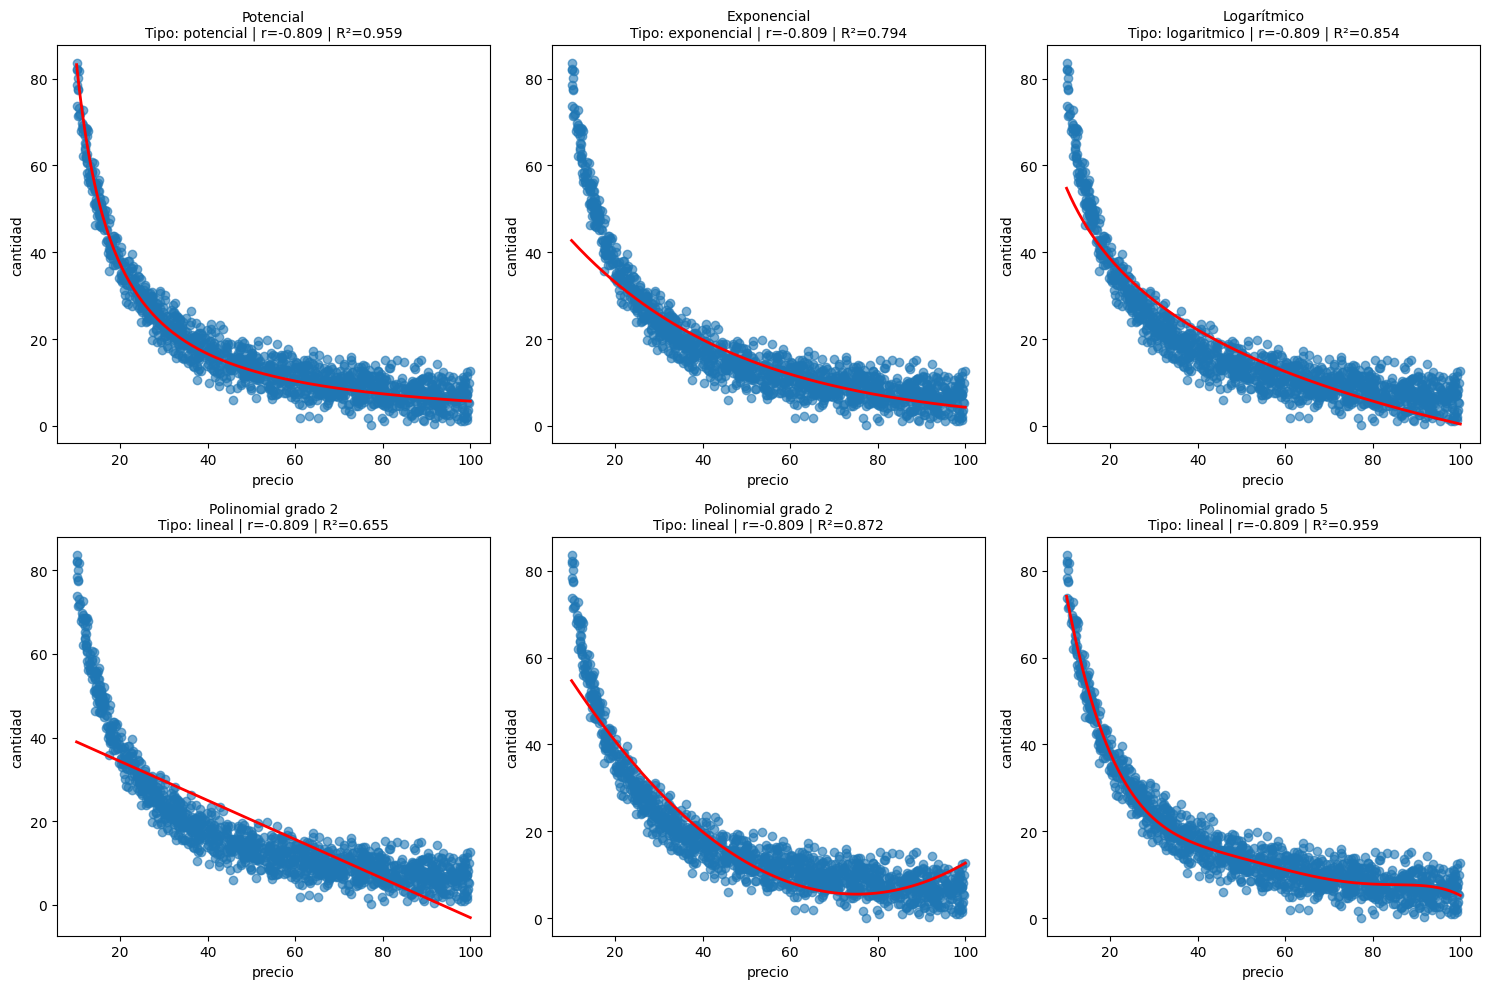

In [10]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial grado 2",
    "Polinomial grado 2",
    "Polinomial grado 5"
]


f_diagrama_dispersion_matriz(
    modelos,
    datos_entrenamiento,
    "precio",
    "cantidad",
    titulos
)

Con la prueba de *Tukey* se observa que ningun modelo presenta linealidad en los residuos, de acuerdo al estadísitico $p-value > 0.05$, todos presentan curvatura en los residuales. Los estadístcos de la prueba de *Tukey* se observan en modo consola habiendo ejecutado la función *f_tukey_linealidad_modelos_plot()*.

Para observar linealidad la linea roja debe ir en concordancia con la linea negra de manera horizontal, ningún modelo presenta el postulado de linealidad,  todos ofrecen curvatura en los residuos

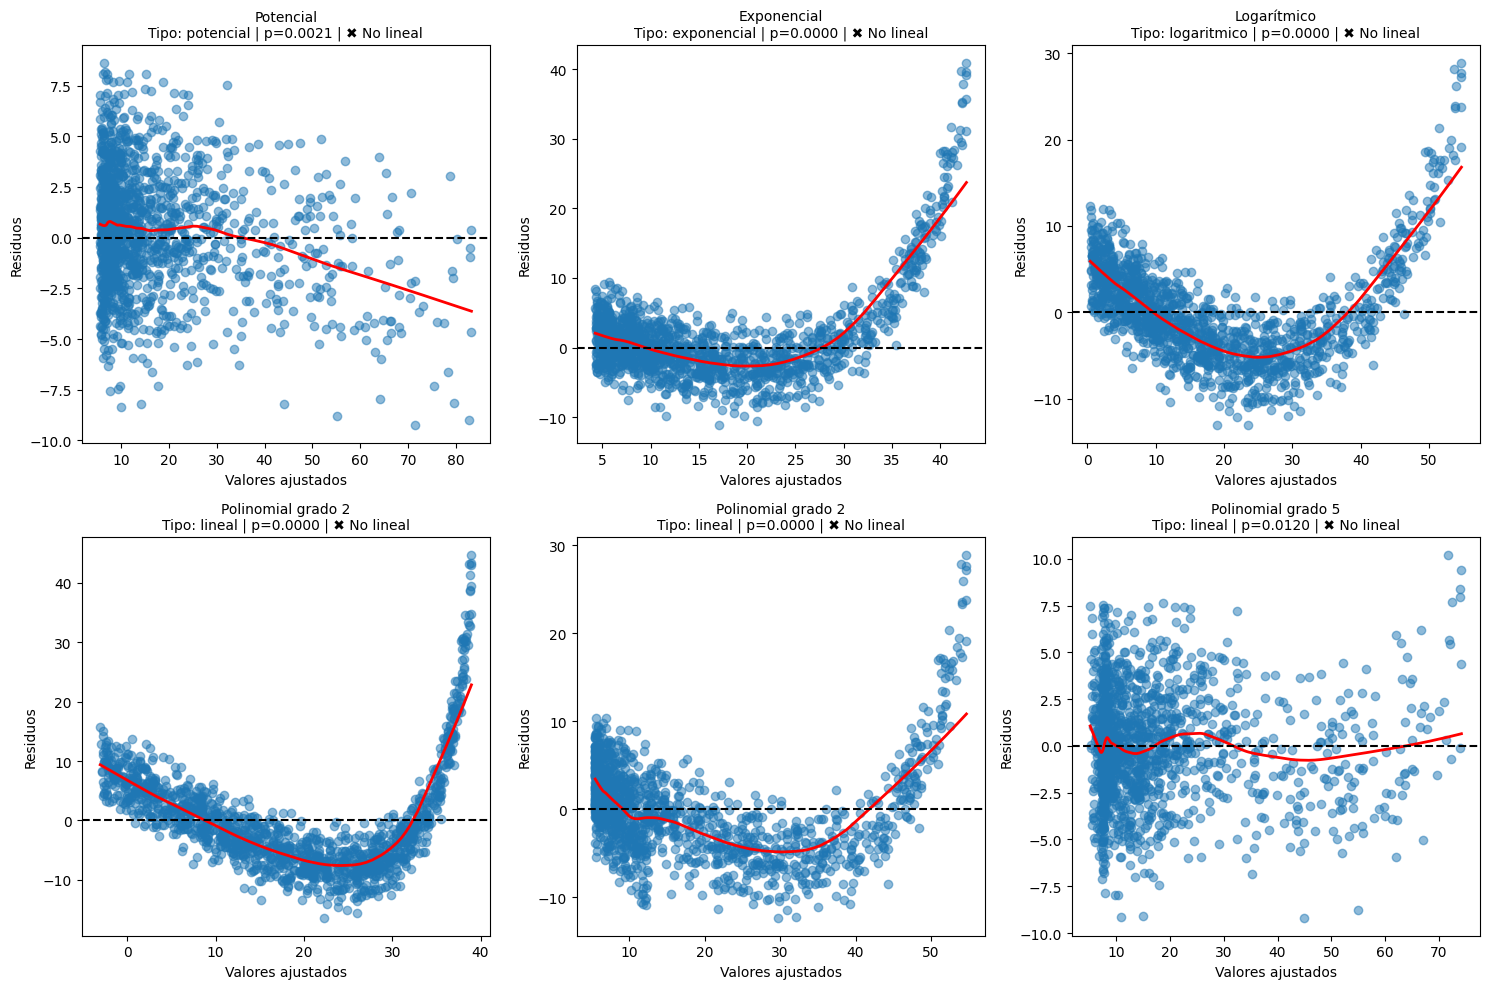

,Modelo,Tipo,p_value,Resultado,Ranking
5,Polinomial grado 5,lineal,0.0120,✖ No lineal,1.0
0,Potencial,potencial,0.0021,✖ No lineal,2.0
2,Logarítmico,logaritmico,0.0000,✖ No lineal,4.5
1,Exponencial,exponencial,0.0000,✖ No lineal,4.5
3,Polinomial grado 2,lineal,0.0000,✖ No lineal,4.5
4,Polinomial grado 2,lineal,0.0000,✖ No lineal,4.5


In [11]:
resultados = f_tukey_linealidad_modelos_plot(
    modelos,
    datos_entrenamiento,
    "precio",
    "cantidad",
    titulos
)

resultados

#### Homocedasticidad

Se ejecuta la función *f_matriz_verificar_homocedasticidad()* la cual visualiza el comportamiento de homocedasticidad en los residuos de los modelos; visualmente ningún modelo tiene condiciones para este postulado, todos se ven con curva o cono en los residuos; de manera parcial el modelo potencial y polinomial de quinto nivel tal vez ofrezcan condiciones.

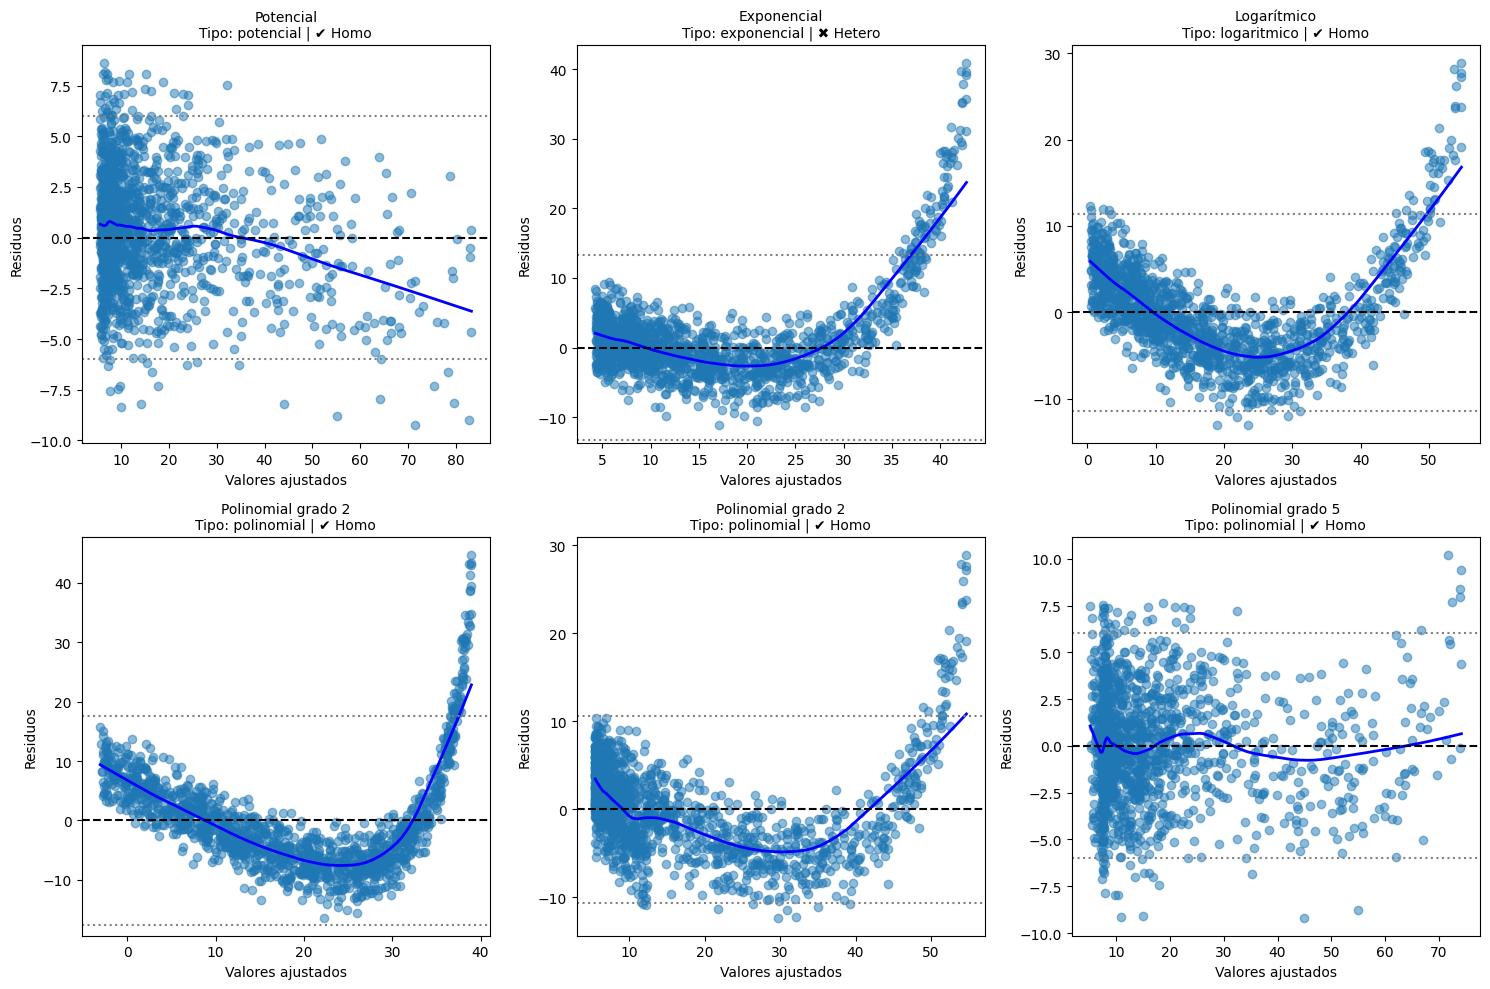

In [12]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

titulos = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial grado 2",
    "Polinomial grado 2",
    "Polinomial grado 5"
]


f_matriz_verificar_homocedasticidad(
    modelos,
    datos_entrenamiento,
    "precio",
    "cantidad",
    titulos
)

Haciendo la prueba de *Breusch-Pagan* y *White* se verifica estadísticamente si los modelos son validados con el postulado  homocedasticidad.

Se ejecuta la función *f_pruebas_homocedasticidad()* la cual devuelve los estadísticos para interpretar las pruebas de *Breusch-Pagan* y *White*.

Los resultados en modo consola, arrojan que nungún modelo pasa las pruebas de homocedasticidad, ni de *Breusch-Pagan* y *White*, el que mas se acerca es el polinomial de quinto orden.


In [13]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

nombres = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial 1",
    "Polinomial 2",
    "Polinomial 5"
]

f_pruebas_homocedasticidad(
    modelos,
    nombres,
    datos_entrenamiento,
    "precio",
    "cantidad"
)

,Modelo,BP_p_value,White_p_value,BP_resultado,White_resultado
0,Potencial,0.000000,0.0,✖ Hetero,✖ Hetero
1,Exponencial,0.000000,0.0,✖ Hetero,✖ Hetero
2,Logarítmico,0.000000,0.0,✖ Hetero,✖ Hetero
3,Polinomial 1,0.000000,0.0,✖ Hetero,✖ Hetero
4,Polinomial 2,0.000000,0.0,✖ Hetero,✖ Hetero
5,Polinomial 5,0.001214,0.0,✖ Hetero,✖ Hetero


#### Normalidad

Se ejecuta la función *f_matriz_normalidad_modelos()* y se observa que solo el modelo polinomial cumple visualmente con que sus residuoos se distribuyen normalmente.

Además con la prueba de *Shapiro-Wilks* se observa que es el munico modelo en donde sus residuales pasan esta prueba.



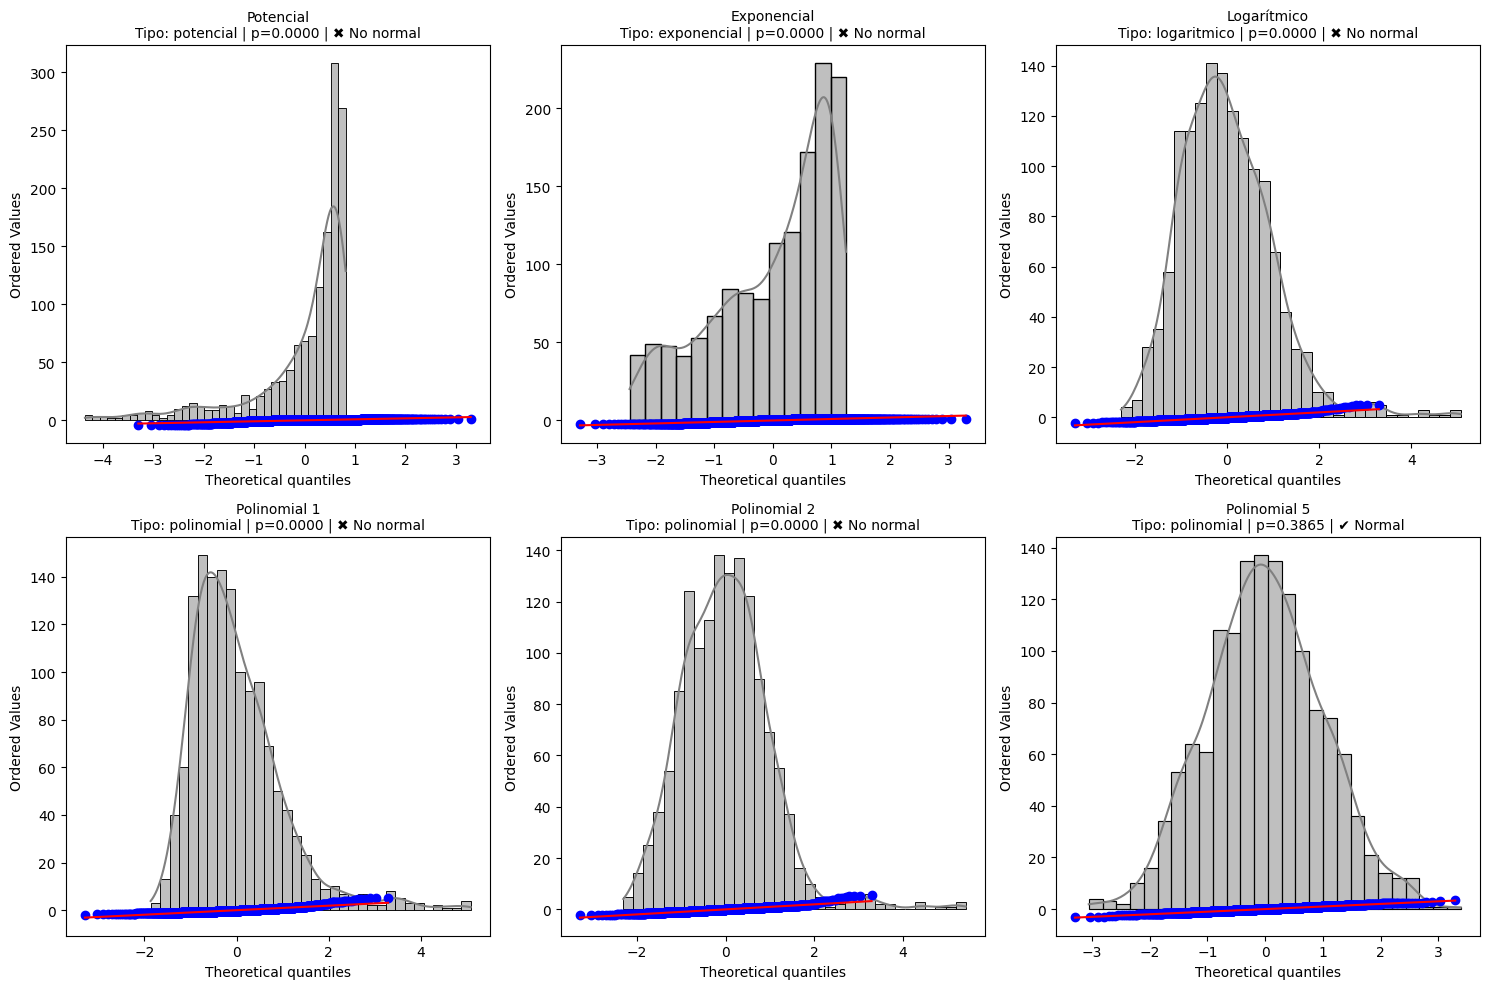

,Modelo,Tipo,p_value,Normalidad,Ranking
5,Polinomial 5,polinomial,0.3865,✔ Normal,1.0
0,Potencial,potencial,0.0000,✖ No normal,4.0
2,Logarítmico,logaritmico,0.0000,✖ No normal,4.0
1,Exponencial,exponencial,0.0000,✖ No normal,4.0
3,Polinomial 1,polinomial,0.0000,✖ No normal,4.0
4,Polinomial 2,polinomial,0.0000,✖ No normal,4.0


In [14]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

nombres = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial 1",
    "Polinomial 2",
    "Polinomial 5"
]

f_matriz_normalidad_modelos(
    modelos,
    datos_entrenamiento,
    "precio",
    "cantidad",
    nombres
)

Se hacen la prueba de normalidad de residuos en los modelos construidos; se ejecuta la función *f_prueba_shapiro(modelos, nombres, datos, x, y)* que hae esta prueba *Shapito Wilks*, recibe los modelos y devuelve un resultado con la prueba y los estadísticos para evaluar si los residuos se comportan bajo una distribución normal.

De los resultados de esta prueba solo el modelo polinomial de quinto orden pasa la prueba de normalidad de *Shapiro-Wilks*.

In [15]:
f_prueba_shapiro(
    modelos,
    nombres,
    datos_entrenamiento,
    "precio",
    "cantidad"
)

,Modelo,Tipo,Shapiro_W,p_value,Normalidad,Ranking
5,Polinomial 5,polinomial,0.9987,0.3865,✔ Normal,1.0
0,Potencial,potencial,0.7251,0.0000,✖ No normal,4.0
2,Logarítmico,logaritmico,0.9535,0.0000,✖ No normal,4.0
1,Exponencial,exponencial,0.9014,0.0000,✖ No normal,4.0
3,Polinomial 1,polinomial,0.8914,0.0000,✖ No normal,4.0
4,Polinomial 2,polinomial,0.9510,0.0000,✖ No normal,4.0


La prueba de normalidad *Amnderson-Darling* de los modelos implementados, solo el modelo polinomial de quinto orden pasa esta prueba. La prueba se ejecutó llamando la función *f_prueba_anderson()*.

In [16]:
f_prueba_anderson(
    modelos,
    nombres,
    datos_entrenamiento,
    "precio",
    "cantidad"
)

,Modelo,Tipo,AD_stat,p_value,Normalidad,Ranking
5,Polinomial 5,polinomial,0.3795,0.4041,✔ Normal,1.0
0,Potencial,potencial,130.2736,0.0000,✖ No normal,4.0
2,Logarítmico,logaritmico,8.2725,0.0000,✖ No normal,4.0
1,Exponencial,exponencial,44.7882,0.0000,✖ No normal,4.0
3,Polinomial 1,polinomial,30.2385,0.0000,✖ No normal,4.0
4,Polinomial 2,polinomial,5.9495,0.0000,✖ No normal,4.0


Ahora mediante la función *f_prueba_kolmogorov()* se hace la prueba de *Kolmogorov-Smirnov* devolviendo los estad´siticos y la interpretación. Sólo el modelo Polinomial de quinto grado para le prueba.


In [17]:
f_prueba_kolmogorov(
    modelos,
    nombres,
    datos_entrenamiento,
    "precio",
    "cantidad"
)

,Modelo,Tipo,KS_stat,p_value,Normalidad,Ranking
5,Polinomial 5,polinomial,0.0143,0.9340,✔ Normal,1.0
4,Polinomial 2,polinomial,0.0431,0.0108,✖ No normal,2.0
2,Logarítmico,logaritmico,0.0513,0.0012,✖ No normal,3.0
0,Potencial,potencial,0.2102,0.0000,✖ No normal,5.0
3,Polinomial 1,polinomial,0.0936,0.0000,✖ No normal,5.0
1,Exponencial,exponencial,0.1252,0.0000,✖ No normal,5.0


#### Independencia de residuos

Al ejecutar la función *f_verificar_independencia_residuos()*, el resultado devuelgto indica que todos los modelso cumplen con el postulao de independencia de residuos dado que el valor de DW está muy cercano a 2 $DW\approx 2$, además el *p-value* no rechaza la $H_0$* de independencia de residos.



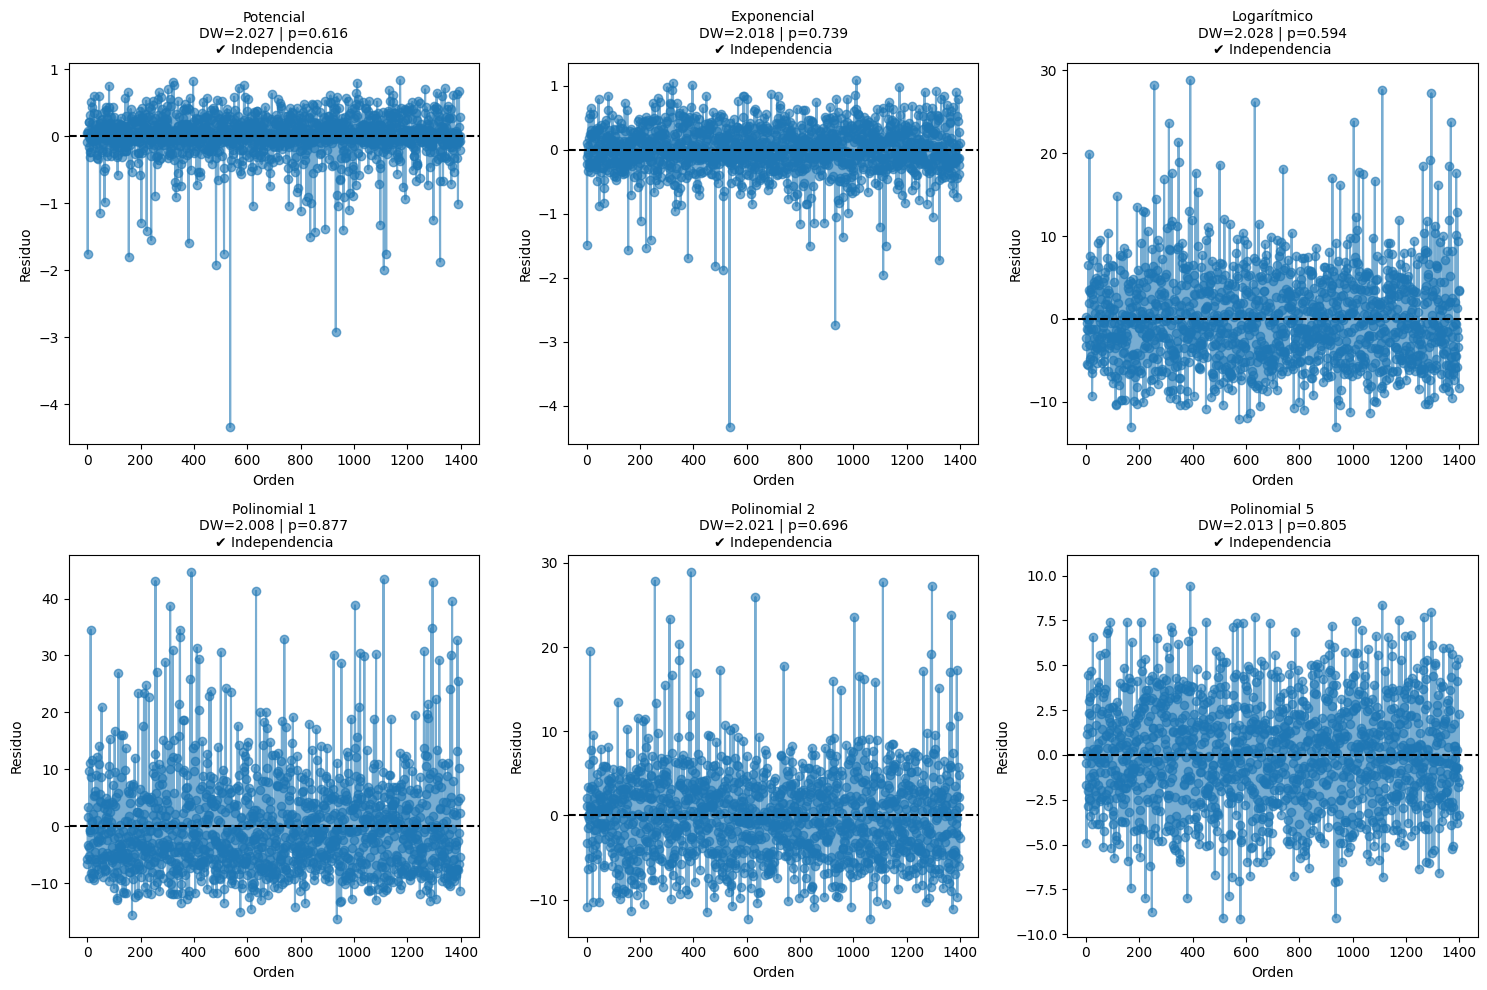

,Modelo,Tipo,DW,p_value,Interpretacion,Decision,Distancia_2,Ranking
3,Polinomial 1,polinomial,2.0077,0.8769,✔ Independencia,No se rechaza H0,0.0077,1.0
5,Polinomial 5,polinomial,2.0130,0.8046,✔ Independencia,No se rechaza H0,0.0130,2.0
1,Exponencial,exponencial,2.0177,0.7390,✔ Independencia,No se rechaza H0,0.0177,3.0
4,Polinomial 2,polinomial,2.0206,0.6960,✔ Independencia,No se rechaza H0,0.0206,4.0
0,Potencial,potencial,2.0267,0.6160,✔ Independencia,No se rechaza H0,0.0267,5.0
2,Logarítmico,logaritmico,2.0281,0.5935,✔ Independencia,No se rechaza H0,0.0281,6.0


In [18]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

nombres = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial 1",
    "Polinomial 2",
    "Polinomial 5"
]

f_verificar_independencia_residuos(
    modelos,
    datos_entrenamiento,
    "precio",
    "cantidad",
    nombres
)

#### Ecuaciones de los modelos

Ejecutando la función *f_ecuaciones_modelos()* se devuelve en modo consola las ecuacines de cada modelo con los valores de los coeficients que permiten interpretar cómo se hacen las predicciones de cada uno de ellos.


In [19]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

nombres = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial 1",
    "Polinomial 2",
    "Polinomial 5"
]

resultados = f_ecuaciones_modelos(
    modelos,
    nombres
)
resultados

,Modelo,Tipo,Ecuacion
0,Potencial,potencial,ŷ = 1250.4578 * precio^-1.1718
1,Exponencial,exponencial,ŷ = 55.312 * e^(-0.0256*precio)
2,Logarítmico,logaritmico,ŷ = 109.5497 - 23.7022*ln(precio)
3,Polinomial 1,polinomial,ŷ = 43.6911 - 0.4676*precio
4,Polinomial 2,polinomial,ŷ = 71.1587 - 1.7471*precio + 0.0116*precio^2
5,Polinomial 5,polinomial,ŷ = 151.9779 - 10.6328*precio + 0.3416*precio^...


#### Evaluación de los modelos

Se ejcuta la función *f_evaluar_modelos_varios()* para evaluar los seis modelos con los estadísticos *r-square* y *RMSE* principalmente.

De todo los modelos con estos datos el que ofrece mejor calidad predictiva es el modelo polinomial de quinto orden para estos datos de este contexto.

In [20]:
modelos = [modelo_pot, modelo_exp, modelo_log, modelo_RP1, modelo_RP2, modelo_RP5]

nombres = [
    "Potencial",
    "Exponencial",
    "Logarítmico",
    "Polinomial 1",
    "Polinomial 2",
    "Polinomial 5"
]

resultado = f_evaluar_modelos_varios(
    modelos,
    datos_validacion,
    "precio",
    "cantidad",
    nombres
)

resultado


,R_square,R_square_ajustado,MSE,RMSE,Parametros (p),Modelo
0,0.9575,0.9571,9.2420,3.0401,6,Polinomial 5
1,0.9557,0.9555,9.6433,3.1054,2,Potencial
2,0.8627,0.8620,29.8778,5.4661,3,Polinomial 2
3,0.8519,0.8514,32.2343,5.6775,2,Logarítmico
4,0.7966,0.7959,44.2758,6.6540,2,Exponencial
5,0.6579,0.6567,74.4537,8.6287,2,Polinomial 1


# Interpretación

El caso de estudio cumple con el objetivo planteado de inicio.

Se utilizaron las librerías y funciones previamente preparadas para la adecuada ejecución del caso. Las funciones se encuentran para su descarga en: https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/funciones_Mpot.py

Los datos para su descarga se encuentran en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_precio_demanda.csv

El caso de estudio para su ejecución y visualización digital se encuentra en https://colab.research.google.com/drive/1V4hhSESqxpgtM2iTVS2xbAa86D7PBp7B?usp=sharing

Para su descarga el caso también se encuentran en plataforma *github.com* https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_modelo_potencuial_precios_cantidad_demanda.ipynb

Se creo un modelo potencial para los datos de precios y cantidades de demanda de un negocio o empresa simulada. Se crearon oros cinco modelo de regresión que sirvieron de comparación: exponencial, logarítmico, polinomiales de primer orden, segundo y quinto grado.

Todos los modelo fueron validados con los supuestos de linealidad, homocedasticidad, normalidad e independencia de residuos.

Con respecto al postulado de linealidad si bien es cierto que el modelo potencial ofrecce mejor linea de tendencia visualmente hablando; estrictamente con la prueba de *Tukey* se observa que ningún modelo presenta linealidad en los residuos y visulmente todos los residuos de los modelos, presentan curvatura.

Con respecto al postulado de homocedasticidad, ningín modleo cumple con esta condición el que más se acerca es el modelo polinomila de quinto orden.

Se hicieron pruebas de normalidad visual y estadísticas con las técnicas de *Shapiro-Wilks*, *Anderson-Darling* y *Kolmogorov-Smirnov*; los resultados indican que solo el modelo polinomial de quinto orden cumple con el postulado de normalidad de los residuos.

Con respecto a la independencia de residuos, los resultados arrojan que todos los modelos cumples con este postulado.

Al comparar los modelos el mejor modelo es el polinomial de quinto orden seguido del modelo potencial de acuerdo a los estadísticos *RMSE* y *r square*.

Por otra parte el modelo que no cumple la expectativa del *70%* la representatividad de la variable dependiente es el modelopolinomial de prierm orden por lo que se conclye que no es un mopdleo adecuado para estos datos de este contexto.

Los estadísticos descriptivos, las ecuaciones y sus coeficientes, las validaciones de los postulados y las comparaciones entr elos modelos de regesión, coinciden con lo visto en el caso de estudio con R para estos datos.




